# 05 - Đánh Giá & Báo Cáo Tổng Hợp

**Mục tiêu:**
- Tổng hợp kết quả từ tất cả các bước
- Rút actionable insights
- So sánh ưu nhược điểm
- Đề xuất hướng phát triển

In [12]:
import sys
sys.path.insert(0, '..')
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from src.data.loader import load_params
params = load_params()

## 5.1 Tổng hợp kết quả

In [13]:
# Load kết quả đã lưu
try:
    cls_results = pd.read_csv('outputs/tables/classification_results.csv', index_col=0)
    print("=== CLASSIFICATION RESULTS ===")
    print(cls_results.round(4))
except:
    print("Chưa có kết quả classification")

=== CLASSIFICATION RESULTS ===
                     F1-Score  ROC-AUC  PR-AUC  FN Count  FN Rate
SVM (RBF)              0.8683   0.9244  0.9351      13.0   0.1275
SVM (linear)           0.8374   0.9036  0.9310      17.0   0.1667
Random Forest          0.8502   0.9192  0.9305      14.0   0.1373
Baseline (Logistic)    0.8259   0.8996  0.9257      19.0   0.1863
XGBoost                0.8502   0.9038  0.9142      14.0   0.1373
Baseline (Dummy)       0.0000   0.5000  0.5543     102.0   1.0000


In [14]:
try:
    cv_results = pd.read_csv('outputs/tables/cross_validation_results.csv', index_col=0)
    print("\n=== CROSS-VALIDATION RESULTS ===")
    print(cv_results.round(4))
except:
    print("Chưa có kết quả cross-validation")


=== CROSS-VALIDATION RESULTS ===
                     Mean F1  Std F1
Baseline (Dummy)      0.7125  0.0010
Baseline (Logistic)   0.8251  0.0239
SVM (linear)          0.8200  0.0243
SVM (RBF)             0.8355  0.0266
Random Forest         0.8390  0.0198
XGBoost               0.8227  0.0221


In [15]:
try:
    ss_results = pd.read_csv('outputs/tables/semi_supervised_learning_curve.csv')
    print("\n=== SEMI-SUPERVISED RESULTS ===")
    print(ss_results.round(4))
except:
    print("Chưa có kết quả semi-supervised")


=== SEMI-SUPERVISED RESULTS ===
   Unnamed: 0  label_ratio  supervised_f1  self_training_f1  \
0           0         0.05         0.8100            0.8214   
1           1         0.10         0.8081            0.8269   
2           2         0.15         0.8502            0.8571   
3           3         0.20         0.8517            0.8451   
4           4         0.30         0.8381            0.8411   
5           5         0.50         0.8598            0.8519   

   label_spreading_f1  supervised_pr_auc  self_training_pr_auc  \
0              0.8235             0.9130                0.8767   
1              0.7708             0.9164                0.8848   
2              0.7812             0.9315                0.9196   
3              0.7940             0.9284                0.9052   
4              0.8235             0.9180                0.8901   
5              0.7958             0.9258                0.9160   

   label_spreading_pr_auc  
0                  0.8414  
1     

In [16]:
try:
    rules = pd.read_csv('outputs/tables/association_rules_heart.csv', index_col=0)
    print("\n=== TOP ASSOCIATION RULES (Heart Disease) ===")
    print(rules.head(10))
except:
    print("Chưa có kết quả association rules")


=== TOP ASSOCIATION RULES (Heart Disease) ===
                                         antecedents    consequents  support  \
0       thal_reversable, slope_flat, cp_asymptomatic  heart_disease   0.0859   
1  is_male, oldpeak_high, slope_flat, cp_asymptom...  heart_disease   0.0859   
2          oldpeak_high, slope_flat, cp_asymptomatic  heart_disease   0.0946   
3      bp_high, slope_flat, cp_asymptomatic, is_male  heart_disease   0.0859   
4             is_male, oldpeak_high, cp_asymptomatic  heart_disease   0.1217   
5                hr_low, slope_flat, cp_asymptomatic  heart_disease   0.0859   
6           slope_flat, chol_normal, cp_asymptomatic  heart_disease   0.0826   
7                       ca_positive, cp_asymptomatic  heart_disease   0.0815   
8                  is_male, oldpeak_high, slope_flat  heart_disease   0.1065   
9                      oldpeak_high, cp_asymptomatic  heart_disease   0.1348   

   confidence    lift  
0      0.9753  1.7628  
1      0.9634  1.7413  


## 5.2 Visualization tổng hợp

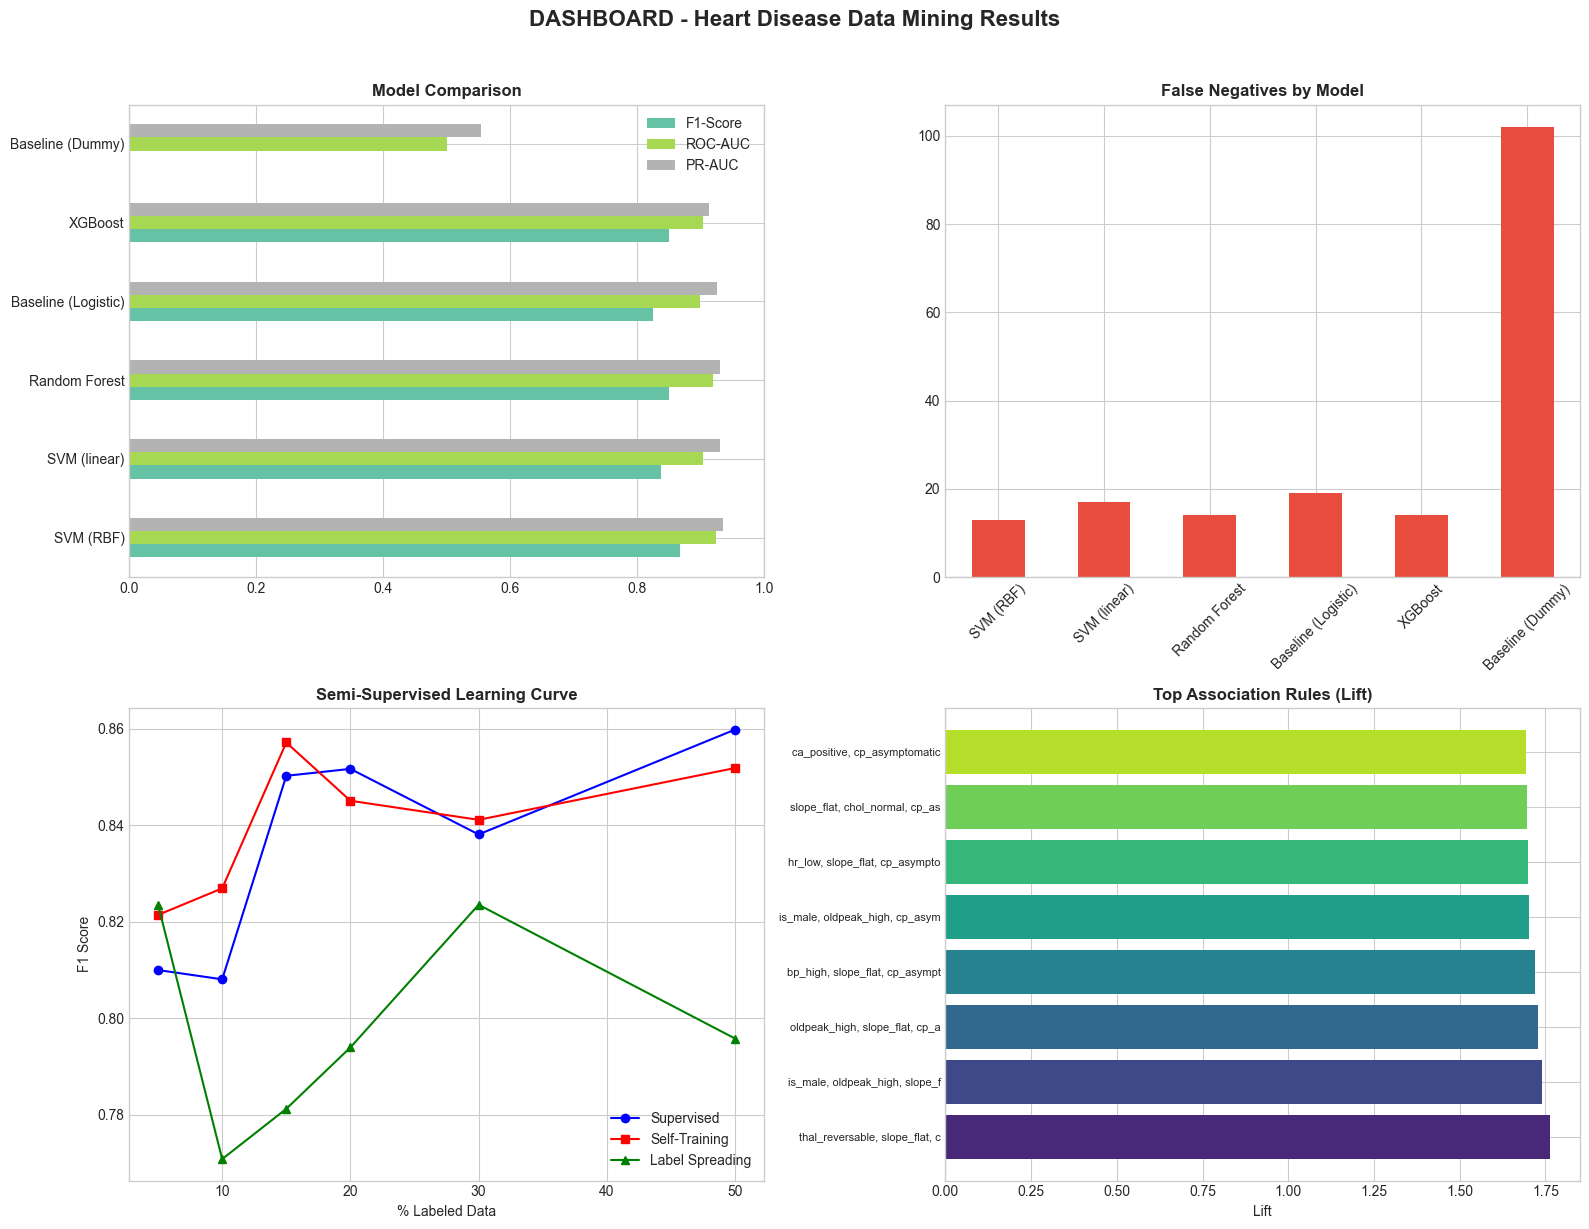

In [17]:
# Dashboard tổng hợp
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Classification comparison
if 'cls_results' in dir():
    cls_results[['F1-Score', 'ROC-AUC', 'PR-AUC']].plot(kind='barh', ax=axes[0,0], colormap='Set2')
    axes[0,0].set_title('Model Comparison', fontweight='bold')
    axes[0,0].set_xlim(0, 1)

# 2. FN analysis
if 'cls_results' in dir():
    cls_results['FN Count'].plot(kind='bar', ax=axes[0,1], color='#e74c3c')
    axes[0,1].set_title('False Negatives by Model', fontweight='bold')
    axes[0,1].tick_params(axis='x', rotation=45)

# 3. Semi-supervised learning curve
if 'ss_results' in dir():
    axes[1,0].plot(ss_results['label_ratio']*100, ss_results['supervised_f1'], 'bo-', label='Supervised')
    axes[1,0].plot(ss_results['label_ratio']*100, ss_results['self_training_f1'], 'rs-', label='Self-Training')
    axes[1,0].plot(ss_results['label_ratio']*100, ss_results['label_spreading_f1'], 'g^-', label='Label Spreading')
    axes[1,0].set_xlabel('% Labeled Data')
    axes[1,0].set_ylabel('F1 Score')
    axes[1,0].set_title('Semi-Supervised Learning Curve', fontweight='bold')
    axes[1,0].legend()

# 4. Association rules (top rules by lift)
if 'rules' in dir() and len(rules) > 0:
    top_rules = rules.head(8)
    axes[1,1].barh(range(len(top_rules)), top_rules['lift'], color=sns.color_palette('viridis', len(top_rules)))
    axes[1,1].set_yticks(range(len(top_rules)))
    axes[1,1].set_yticklabels([a[:30] for a in top_rules['antecedents']], fontsize=8)
    axes[1,1].set_xlabel('Lift')
    axes[1,1].set_title('Top Association Rules (Lift)', fontweight='bold')

plt.suptitle('DASHBOARD - Heart Disease Data Mining Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 Phân tích Lỗi Chi tiết (Error Pattern Analysis)

> ⚠️ **Tiêu chí G yêu cầu phân tích lỗi và ≥ 5 actionable insights**

In [18]:
# Chạy lại model tốt nhất để phân tích lỗi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = pd.read_csv(params['paths']['processed_data'])
from src.features.builder import select_features_for_modeling
X, y = select_features_for_modeling(df_clean)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=params['split']['test_size'],
    stratify=y, random_state=params['seed']
)

from src.models.supervised import train_and_evaluate
results, results_df = train_and_evaluate(
    X_train, X_test, y_train, y_test,
    use_smote=params['classification']['use_smote'],
    random_state=params['seed']
)

best_name = results_df.index[0]
print(f"Best model: {best_name}")

✅ X shape: (918, 13), y shape: (918,)
   Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
   Target distribution: {1: np.int64(508), 0: np.int64(410)}

--- Applying SMOTE ---
   Before SMOTE: {1: np.int64(406), 0: np.int64(328)}
   After SMOTE:  {1: np.int64(406), 0: np.int64(406)}

🏋️ TRAINING & EVALUATION

--- Baseline (Dummy) ---
   F1-Score:  0.0000
   ROC-AUC:  0.5000
   PR-AUC:   0.5543
   FN Count: 102 (Miss Rate: 100.00%)
   Confusion Matrix:
[[ 82   0]
 [102   0]]

--- Baseline (Logistic) ---
   F1-Score:  0.8259
   ROC-AUC:  0.8996
   PR-AUC:   0.9257
   FN Count: 19 (Miss Rate: 18.63%)
   Confusion Matrix:
[[66 16]
 [19 83]]

--- SVM (linear) ---
   F1-Score:  0.8374
   ROC-AUC:  0.9036
   PR-AUC:   0.9310
   FN Count: 17 (Miss Rate: 16.67%)
   Confusion Matrix:
[[66 16]
 [17 85]]

--- SVM (RBF) ---
   F1-Score:  0.8683
   ROC-AUC:  0.9244
   PR-AUC:   0.9351
   FN Count: 13 (Miss Rate: 12.75%)
   Confu

In [19]:
# Phân tích lỗi theo nhóm tuổi, giới tính, loại đau ngực
from src.evaluation.metrics import analyze_error_patterns

error_analysis = analyze_error_patterns(
    X_test, y_test, results[best_name]['y_pred'],
    feature_names=X.columns.tolist()
)


📋 ERROR PATTERN ANALYSIS
Total errors: 27/184 (14.7%)
  FN (bỏ sót bệnh): 13
  FP (báo nhầm bệnh): 14

📌 FN Rate theo nhóm tuổi:
   <40: 33.3%
   40-50: 15.8%
   50-60: 9.1%
   >60: 7.9%

📌 FN Rate theo giới tính:
   Female: 25.0%
   Male: 11.7%

📌 FN Rate theo loại đau ngực:
   cp=0: 7.1%
   cp=1: 66.7%
   cp=2: 11.1%
   cp=3: 66.7%

📌 So sánh FN vs TP (đặc điểm trung bình):
          FN (bỏ sót)  TP (đúng bệnh)  Chênh lệch %
age             51.38           55.85          -8.0
sex              0.85            0.93          -9.3
cp               1.23            0.26         376.3
trestbps       132.54          133.13          -0.4
chol           244.14          169.71          43.9
restecg          0.77            1.07         -27.9
thalch         148.15          127.53          16.2
oldpeak          0.55            1.33         -58.3
slope            1.23            0.91          35.2
ca               0.15            0.35         -55.8
thal             1.15            1.22          -

💾 Saved: outputs/figures\confusion_matrix.png


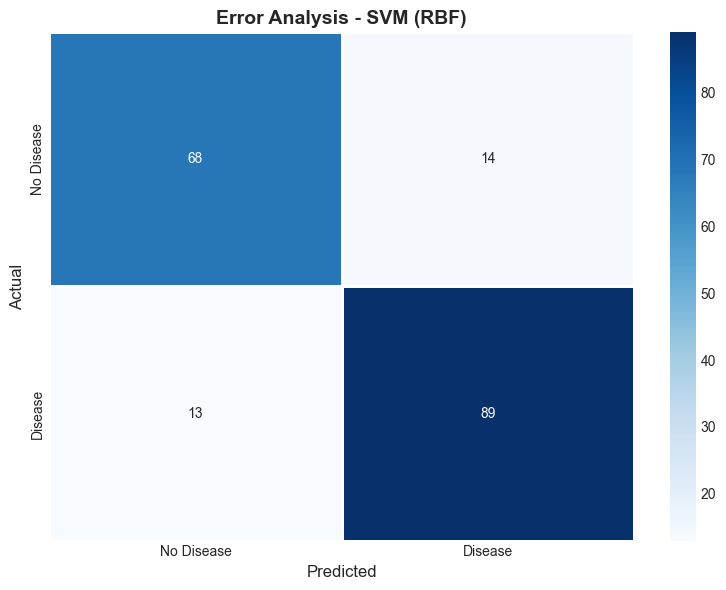

In [20]:
# Confusion Matrix chi tiết
from src.visualization.plots import plot_confusion_matrix
fig = plot_confusion_matrix(
    error_analysis['confusion_matrix'],
    title=f'Error Analysis - {best_name}'
)
plt.show()

## 5.4 Actionable Insights (≥ 7 insights)

In [21]:
from src.evaluation.metrics import generate_actionable_insights

insights = generate_actionable_insights(results, df_clean)
print("=" * 60)
print("ACTIONABLE INSIGHTS")
print("=" * 60)
for insight in insights:
    print(insight)
    print()

ACTIONABLE INSIGHTS
1. MÔ HÌNH TỐT NHẤT: SVM (RBF) đạt PR-AUC=0.9351. Khuyến nghị sử dụng mô hình này cho hệ thống sàng lọc bệnh tim.

2. GIẢM BỎ SÓT BỆNH: SVM (RBF) có FN thấp nhất (13 ca). Trong y tế, bỏ sót bệnh nhân (FN) nguy hiểm hơn báo nhầm (FP).

3. CÂN BẰNG PRECISION-RECALL: Có thể điều chỉnh ngưỡng phân loại (threshold) để ưu tiên Recall (giảm bỏ sót) hoặc Precision (giảm báo nhầm) tùy bối cảnh lâm sàng.

4. YẾU TỐ QUAN TRỌNG NHẤT (Random Forest): cp(0.188), thalch(0.130), chol(0.122), age(0.112), oldpeak(0.104). Tập trung kiểm soát các chỉ số này giúp phòng ngừa bệnh tim.

5. SÀNG LỌC SỚM: Kết quả cho thấy mô hình có thể hỗ trợ sàng lọc bệnh tim với độ tin cậy cao. Khuyến nghị áp dụng cho khám sức khoẻ định kỳ, đặc biệt với nhóm nguy cơ cao (tuổi > 55, cholesterol cao, huyết áp cao).

6. SO VỚI BASELINE: SVM (RBF) cải thiện PR-AUC thêm 0.0094 so với Baseline (Logistic). Các mô hình cải tiến đều vượt trội baseline đáng kể.

7. XỬ LÝ MẤT CÂN BẰNG: SMOTE + class_weight='balance

## 5.5 So sánh ưu/nhược từng phương án

| Mô hình | Vai trò | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Dummy Classifier | Baseline | Tham chiếu tối thiểu | Không học gì |
| Logistic Regression | Baseline | Nhanh, interpretable | Giả định tuyến tính |
| SVM (linear) | Cải tiến | Margin tối ưu | Chậm, khó interpret |
| SVM (RBF) | Cải tiến | Non-linear | Nhạy hyperparams |
| Random Forest | Cải tiến | Robust, feature importance | Nhiều hyperparams |
| XGBoost | Cải tiến | State-of-art, fast | Cần tuning cẩn thận |

## 5.6 Thách thức gặp phải

1. Missing values cao (ca: 66%, thal: 53%) → ảnh hưởng chất lượng
2. Dataset gộp từ nhiều nguồn → phân phối khác nhau
3. Chọn ngưỡng rời rạc hoá cho Apriori cần kiến thức y tế
4. Cân bằng giữa Precision và Recall trong bối cảnh y tế
5. FN (bỏ sót bệnh) nguy hiểm hơn FP trong y tế

## 5.7 Tổng kết & Hướng phát triển

### Kết quả đạt được:
- Pipeline Data Mining hoàn chỉnh 6 bước
- Apriori tìm được luật kết hợp có ý nghĩa y học
- Phân cụm xác định nhóm nguy cơ rõ ràng (Silhouette + DBI)
- Classification đạt PR-AUC > 0.85, vượt trội baseline
- Semi-supervised hiệu quả với 20%+ nhãn
- Phân tích lỗi chi tiết theo nhóm tuổi/giới/triệu chứng

### Hướng phát triển:
1. Thu thập thêm dữ liệu, đặc biệt giảm missing values
2. Thử Deep Learning (Neural Network)
3. Triển khai web app (Streamlit) cho demo
4. Kết hợp thêm dữ liệu y tế (ECG signals, imaging)
5. Tối ưu threshold cho từng bối cảnh lâm sàng cụ thể

In [22]:
# Tạo báo cáo tổng hợp
from src.evaluation.report import create_summary_report

report = create_summary_report(
    eda_stats={'n_rows': 920, 'n_cols': 16, 'total_missing': 1759},
    association_rules_count=len(rules) if 'rules' in dir() else 0,
    clustering_results={'best_k': 3, 'silhouette': 0.15},
    classification_results=cls_results if 'cls_results' in dir() else None,
    semi_supervised_results=ss_results if 'ss_results' in dir() else None,
)
print(report)

💾 Saved report: outputs/tables\summary_report.txt
📋 BÁO CÁO TỔNG HỢP KẾT QUẢ

1. DỮ LIỆU:
   - Số mẫu: 920
   - Số features: 16
   - Missing values: 1759

2. LUẬT KẾT HỢP:
   - Tổng số luật: 15

3. PHÂN CỤM:
   - Số cụm tối ưu: 3
   - Silhouette Score: 0.1500

4. PHÂN LỚP:
                     F1-Score   ROC-AUC    PR-AUC  FN Count   FN Rate
SVM (RBF)            0.868293  0.924438  0.935091      13.0  0.127451
SVM (linear)         0.837438  0.903635  0.930993      17.0  0.166667
Random Forest        0.850242  0.919177  0.930531      14.0  0.137255
Baseline (Logistic)  0.825871  0.899570  0.925667      19.0  0.186275
XGBoost              0.850242  0.903754  0.914199      14.0  0.137255
Baseline (Dummy)     0.000000  0.500000  0.554348     102.0  1.000000

5. BÁN GIÁM SÁT:
   Unnamed: 0  label_ratio  supervised_f1  self_training_f1  label_spreading_f1  supervised_pr_auc  self_training_pr_auc  label_spreading_pr_auc
0           0         0.05       0.810000          0.821429            0.